In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")

# Etapa 1 Compreensão e qualidade dos dados

## Exercício 1 Inspeção inicial

1. as cinco primeiras linhas;
2. a quantidade de linhas e colunas;
3. os tipos das variáveis;
4. as estatísticas descritivas;
5. a quantidade e o percentual de valores ausentes.

In [21]:
display(df.head())

print("Dimensão:",df.shape)

print("Tipos de dados:")
display(df.dtypes.to_frame("tipo"))

df.describe()

valores_ausentes = pd.DataFrame({
    'Quantidade': df.isnull().sum(),
    'Percentual (%)': (df.isnull().mean() * 100).round(2)
})
valores_ausentes[valores_ausentes['Quantidade'] > 0].sort_values(by='Quantidade', ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Dimensão: (891, 12)
Tipos de dados:


,tipo
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64


,Quantidade,Percentual (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


## Exercício 2 Tipos e qualidade

Classifique as principais variáveis como categóricas, numéricas, identificadoras ou textuais. Em seguida,
verifique:
* valores ausentes;
* registros duplicados;
* idades ou tarifas inválidas;

In [14]:
print(df['Age'].max())

80.0


In [17]:
valores_ausentes = df.isnull().sum()
print("Valores Ausentes:")
print(valores_ausentes[valores_ausentes > 0])
print("\n")

registros_duplicados = df.duplicated().sum()
print("Registros Duplicados:")
print(f"Total de linhas duplicadas: {registros_duplicados}\n")

idades_invalidas = df[df['Age'] < 0]
tarifas_invalidas = df[df['Fare'] < 0]

print("Valores Inválidos:")
print(f"Idades inválidos: {len(idades_invalidas)}")
print(f"Tarifas inválidos: {len(tarifas_invalidas)}\n")

print("--- Consistência das Categorias ---")
print(f"Sex (esperado: male, female): {df['Sex'].unique()}")
print(f"Embarked (esperado: S, C, Q, nan): {df['Embarked'].unique()}")
print(f"Pclass (esperado: 1, 2, 3): {df['Pclass'].unique()}")
print(f"Survived (esperado: 0, 1): {df['Survived'].unique()}")

Valores Ausentes:
Age         177
Cabin       687
Embarked      2
dtype: int64


Registros Duplicados:
Total de linhas duplicadas: 0

Valores Inválidos:
Idades inválidos: 0
Tarifas inválidos: 0

--- Consistência das Categorias ---
Sex (esperado: male, female): <ArrowStringArray>
['male', 'female']
Length: 2, dtype: str
Embarked (esperado: S, C, Q, nan): <ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
Pclass (esperado: 1, 2, 3): [3 1 2]
Survived (esperado: 0, 1): [0 1]


### Alto volume de dados ausentes em Cabin

**O Risco:** A coluna Cabin possui mais de 75% de valores nulos. Com uma ausência tão massiva, tentar preencher esses dados com estatísticas (imputação) introduzirá muito ruído e viés ao modelo.

**Tratamento Proposto:** Descartar a coluna original por não ter significância estatística direta na sua forma bruta. Alternativamente, criar uma nova variável categórica binária chamada Possui_Cabine (1 para quem tinha cabine registrada e 0 para nulo), pois o simples fato de ter o registro da cabine pode estar associado ao status socioeconômico do passageiro.

In [29]:
df_tratado = df.copy()

df_tratado['Possui_Cabine'] = df_tratado['Cabin'].notna().astype(int)

df_tratado.drop('Cabin', axis=1, inplace=True)

display(df_tratado[['PassengerId', 'Name', 'Possui_Cabine']].head())

,PassengerId,Name,Possui_Cabine
0,1,"Braund, Mr. Owen Harris",0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,3,"Heikkinen, Miss. Laina",0
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
4,5,"Allen, Mr. William Henry",0


### Ausência moderada de dados em Age

**O Risco:** Cerca de 20% das idades estão faltando. Excluir as linhas com idades nulas resultaria na perda de 20% dos registros do dataset, reduzindo o poder da análise modelo.

**Tratamento Proposto:** Imputação de dados. Em vez de usar a média global, que pode distorcer a realidade, preencha os valores vazios com a mediana da idade agrupada pela classe do passageiro e pelo sexo. Assim, um homem da 3ª classe sem idade registrada receberá a idade mediana dos outros homens da 3ª classe.

In [34]:
df_tratado['Age'] = df_tratado.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

print("Valores ausentes em 'Age':", df_tratado['Age'].isnull().sum())

Valores ausentes em 'Age': 0


### Valores nulos marginais em Embarked

**O Risco:** Faltam apenas 2 valores nesta coluna. Embora seja uma quantidade irrisória estatisticamente, a presença de qualquer valor NaN fará com que a maioria dos algoritmos de Machine Learning (como os do Scikit-Learn) retorne um erro no momento do treinamento.

**Tratamento Proposto:** Substituir os dois valores faltantes pela moda. Como a esmagadora maioria dos passageiros embarcou em Southampton, preencher esses nulos com 'S'.

In [35]:
df_tratado['Embarked'].fillna('S', inplace=True)

/tmp/ipykernel_11137/2909937296.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_tratado['Embarked'].fillna('S', inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

# Etapa 2 Análise univariada

## Exercício 3 Sobrevivência e classe

Calcule e visualize:
* a quantidade e a proporção de sobreviventes;
* a quantidade de passageiros por classe;
* a distribuição dos passageiros por sexo.
Para cada gráfico, registre um achado, uma interpretação e uma limitação.

Sobreviventes:
Quantidade:
Survived
0    549
1    342
Name: count, dtype: int64

Proporção (%):
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

Passageiros por Classe:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Passageiros por Sexo:
Sex
male      577
female    314
Name: count, dtype: int64



/tmp/ipykernel_11137/2288013403.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tratado, x='Survived', palette='pastel', ax=axes[0])
/tmp/ipykernel_11137/2288013403.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
/tmp/ipykernel_11137/2288013403.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tratado, x='Pclass', palette='Set2', ax=axes[1])
/tmp/ipykernel_11137/2288013403.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

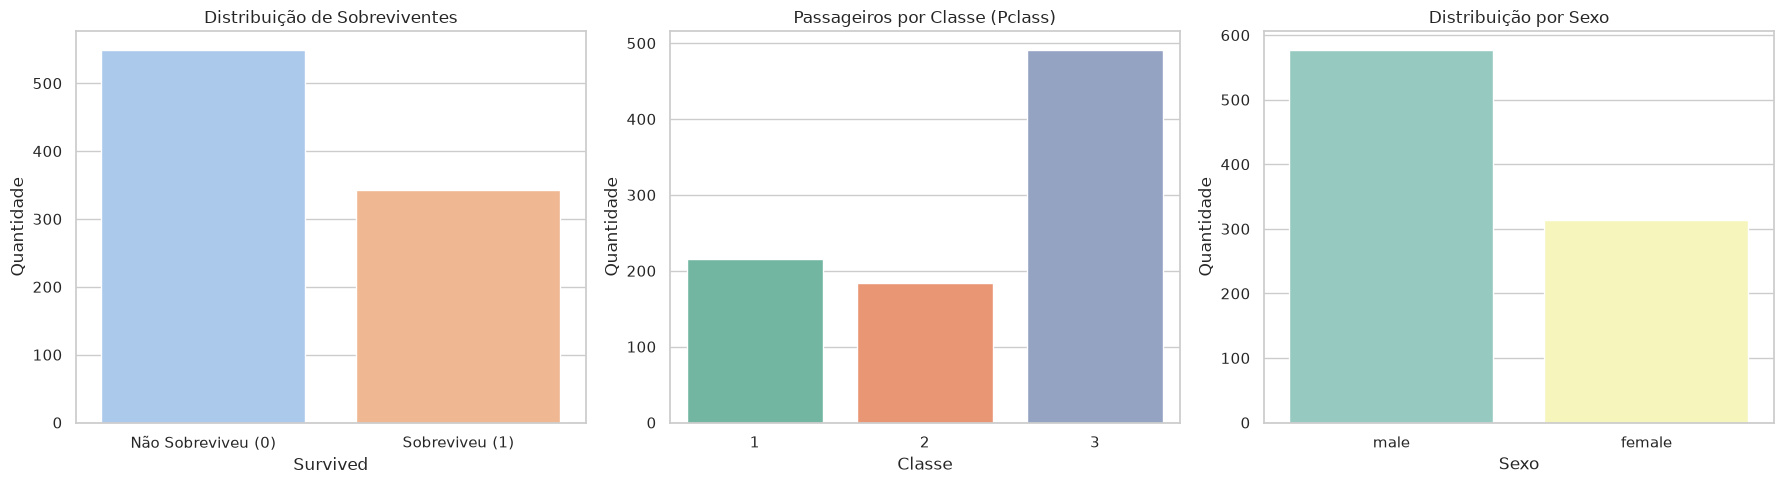

In [54]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quantidade e proporção de sobreviventes
qtde_sobreviventes = df_tratado['Survived'].value_counts()
prop_sobreviventes = df_tratado['Survived'].value_counts(normalize=True) * 100

print("Sobreviventes:")
print(f"Quantidade:\n{qtde_sobreviventes}\n")
print(f"Proporção (%):\n{prop_sobreviventes.round(2)}\n")

sns.countplot(data=df_tratado, x='Survived', palette='pastel', ax=axes[0])
axes[0].set_title('Distribuição de Sobreviventes')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(['Não Sobreviveu (0)', 'Sobreviveu (1)'])


# Quantidade de passageiros por classe
qtde_classe = df_tratado['Pclass'].value_counts().sort_index()

print("Passageiros por Classe:")
print(f"{qtde_classe}\n")

sns.countplot(data=df_tratado, x='Pclass', palette='Set2', ax=axes[1])
axes[1].set_title('Passageiros por Classe (Pclass)')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Quantidade')


# Distribuição dos passageiros por sexo
qtde_sexo = df_tratado['Sex'].value_counts()

print("Passageiros por Sexo:")
print(f"{qtde_sexo}\n")

sns.countplot(data=df_tratado, x='Sex', palette='Set3', ax=axes[2])
axes[2].set_title('Distribuição por Sexo')
axes[2].set_xlabel('Sexo')
axes[2].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

### Análise dos Gráficos

**Gráfico 1: Sobrevivência**

* **Achado:** Aproximadamente 61,6% dos passageiros não sobreviveram (cerca de 549 pessoas), enquanto apenas 38,4% sobreviveram (cerca de 342 pessoas).
* **Interpretação:** A alta taxa de mortalidade reflete a gravidade do naufrágio e a insuficiência de botes salva-vidas e procedimentos de evacuação para atender a todos os passageiros a bordo.
* **Limitação:** Analisar a sobrevivência de forma global esconde os vieses demográficos do resgate. Não é possível saber por este gráfico isolado quem teve prioridade no salvamento.

**Gráfico 2: Passageiros por Classe**

* **Achado:** A esmagadora maioria dos passageiros estava na 3ª classe (mais de 490 pessoas), superando a soma dos passageiros da 1ª e 2ª classes juntas.
* **Interpretação:** O navio era ocupado predominantemente por passageiros de menor poder aquisitivo, muitos dos quais eram imigrantes viajando para os Estados Unidos em busca de melhores condições de vida, em contraste com a elite viajando a lazer na 1ª classe.
* **Limitação:** O gráfico considera apenas os passageiros pagantes. Ele omite completamente a tripulação do navio, o que não nos dá a visão completa da densidade populacional e da divisão estrutural total dentro do Titanic.

**Gráfico 3: Distribuição por Sexo**

* **Achado:** Havia uma quantidade significativamente maior de homens (quase 65%) em comparação às mulheres (cerca de 35%).
* **Interpretação:** Reflete o perfil migratório e socioeconômico da época (1912), onde era mais comum que homens viajassem sozinhos a trabalho ou para estabelecer-se em um novo país antes de enviar buscar suas famílias.
* **Limitação:** O gráfico fornece apenas uma visão demográfica estática. Sem cruzar essa variável com a taxa de sobrevivência (como "mulheres e crianças primeiro"), o impacto prático do gênero na probabilidade de sobrevivência permanece oculto.

## Exercício 4 Distribuição das idades
Para a variável Age, calcule média, mediana, quartis, desvio padrão, mínimo e máximo. Produza um
histograma e um boxplot.
Responda:
* A distribuição é simétrica?
* Média e mediana são próximas?
* Existem valores extremos?
* Um valor extremo deve ser automaticamente removido?

--- Estatísticas Descritivas: Idade (Age) ---
Média: 29.11
Mediana: 26.00
1º Quartil (25%): 21.50
2º Quartil / Mediana (50%): 26.00
3º Quartil (75%): 36.00
Desvio Padrão: 13.30
Mínimo: 0.42
Máximo: 80.00



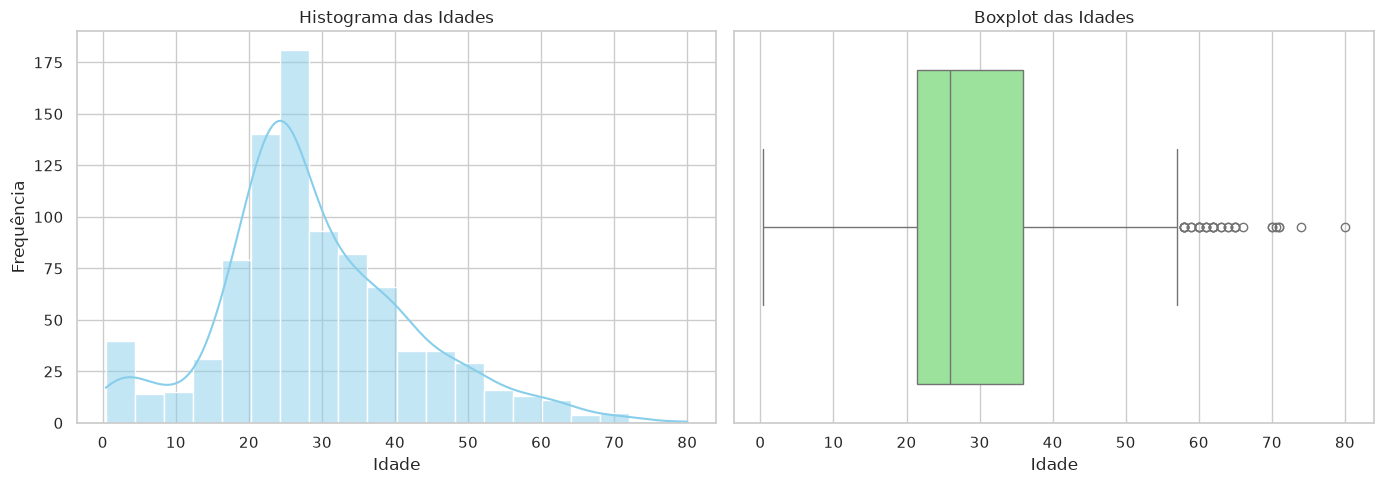

In [75]:
# Cálculos estatísticos da variável Age
media = df_tratado['Age'].mean()
mediana = df_tratado['Age'].median()
quartis = df_tratado['Age'].quantile([0.25, 0.50, 0.75])
desvio_padrao = df_tratado['Age'].std()
minimo = df_tratado['Age'].min()
maximo = df_tratado['Age'].max()

print("--- Estatísticas Descritivas: Idade (Age) ---")
print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"1º Quartil (25%): {quartis[0.25]:.2f}")
print(f"2º Quartil / Mediana (50%): {quartis[0.50]:.2f}")
print(f"3º Quartil (75%): {quartis[0.75]:.2f}")
print(f"Desvio Padrão: {desvio_padrao:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}\n")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
sns.histplot(data=df_tratado, x='Age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Histograma das Idades')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')

# Boxplot
sns.boxplot(data=df_tratado, x='Age', color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot das Idades')
axes[1].set_xlabel('Idade')

plt.tight_layout()
plt.show()

## Análise dos Resultados

**A distribuição é simétrica?**

Não, ela apresenta uma leve assimetria à direita (assimetria positiva). O maior volume de passageiros concentra-se na faixa dos 20 aos 30 anos, formando um pico central, mas a distribuição forma uma "cauda" mais longa em direção às idades mais avançadas. Nota analítica: devido à imputação pela mediana feita no passo anterior, o histograma exibirá picos mais acentuados nas idades de 26 e 29 anos, reforçando o peso do centro da distribuição.

**Média e mediana são próximas?**

Sim. Ambas ficam na casa dos 29 anos no dataset tratado. Essa proximidade indica que, apesar da cauda à direita e da presença de bebês (valores próximos a zero), o centro de massa dos dados é consistente. A média costuma ficar fracionariamente acima da mediana, puxada para cima pelos passageiros mais velhos.

**Existem valores extremos?**

Sim. Ao observar o boxplot, você notará diversos pontos desenhados do lado de fora da linha (o "bigode") superior do gráfico. Na estatística, esses pontos representam passageiros com idades avançadas (neste dataset, geralmente acima dos 60 anos) que fogem da densidade demográfica padrão da tripulação.

**Um valor extremo deve ser automaticamente removido?**

Definitivamente não. No contexto do Titanic, um passageiro de 75 ou 80 anos é um dado real e perfeitamente possível, não um erro de sensor ou de digitação. Remover esses valores automaticamente (outliers legítimos) distorceria a realidade demográfica da viagem e prejudicaria a precisão de um modelo preditivo, visto que a idade avançada pode ter influenciado diretamente as chances de não conseguir um lugar nos botes salva-vidas. Valores extremos só devem ser descartados se representarem um erro comprovado na coleta (como uma idade de 150 anos ou um valor negativo).

## Exercício 5 Distribuição das tarifas

Analise Fare por meio de estatísticas descritivas, histograma e boxplot. Compare média e mediana e
explique o que a diferença entre elas revela sobre a distribuição.

--- Estatísticas Descritivas: Tarifas (Fare) ---
Média: 32.20
Mediana: 14.45
1º Quartil (25%): 7.91
2º Quartil / Mediana (50%): 14.45
3º Quartil (75%): 31.00
Desvio Padrão: 49.69
Mínimo: 0.00
Máximo: 512.33



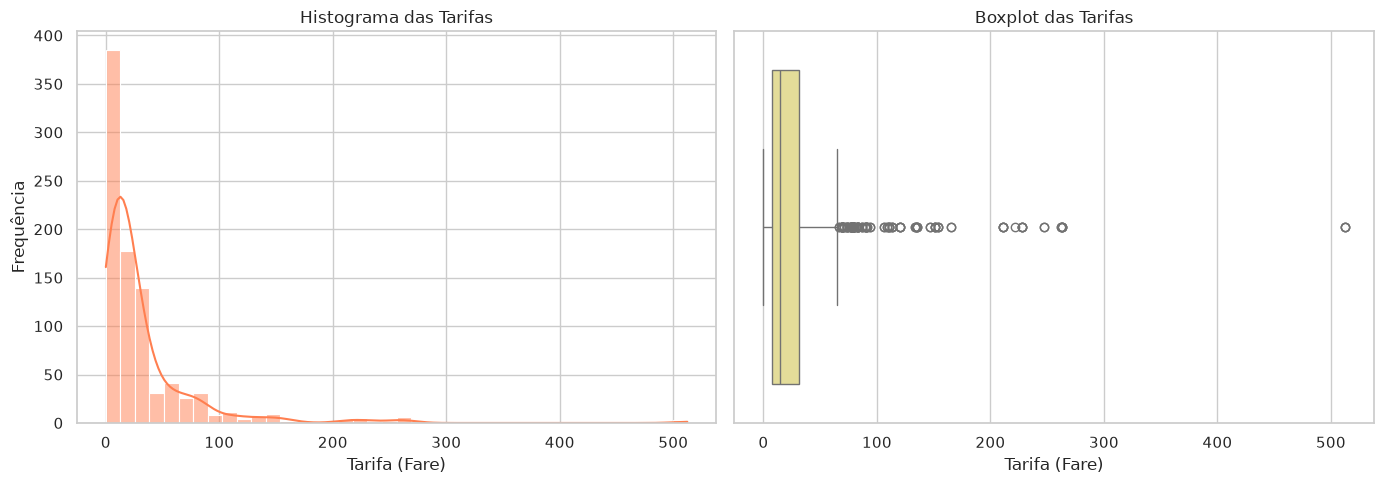

In [83]:
# Cálculos estatísticos da variável Fare
media = df_tratado['Fare'].mean()
mediana = df_tratado['Fare'].median()
quartis = df_tratado['Fare'].quantile([0.25, 0.50, 0.75])
desvio_padrao = df_tratado['Fare'].std()
minimo = df_tratado['Fare'].min()
maximo = df_tratado['Fare'].max()

print("--- Estatísticas Descritivas: Tarifas (Fare) ---")
print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"1º Quartil (25%): {quartis[0.25]:.2f}")
print(f"2º Quartil / Mediana (50%): {quartis[0.50]:.2f}")
print(f"3º Quartil (75%): {quartis[0.75]:.2f}")
print(f"Desvio Padrão: {desvio_padrao:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}\n")

# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma (com a curva de densidade KDE)
sns.histplot(data=df_tratado, x='Fare', bins=40, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Histograma das Tarifas')
axes[0].set_xlabel('Tarifa (Fare)')
axes[0].set_ylabel('Frequência')

# Boxplot
sns.boxplot(data=df_tratado, x='Fare', color='khaki', ax=axes[1])
axes[1].set_title('Boxplot das Tarifas')
axes[1].set_xlabel('Tarifa (Fare)')

plt.tight_layout()
plt.show()

### Análise: Média vs. Mediana e a Distribuição

**Uma diferença drástica entre os indicadores centrais:**

A Média gira em torno de 32.20.

A Mediana é exatos 14.45.


Como a média é muito maior que a mediana, isso indica uma distribuição fortemente assimétrica à direita (assimetria positiva).

Isso acontece porque a variável Fare possui valores extremos (outliers) muito altos. Enquanto a esmagadora maioria dos passageiros viajava na 3ª classe pagando tarifas baratas (o que empurra a mediana para baixo, já que 50% dos passageiros pagaram 14.45 ou menos), uma minoria na 1ª classe pagou quantias exorbitantes (como o valor máximo de 512.32).

Esses poucos bilhetes de luxo puxam o valor da média aritmetica fortemente para cima, tornando-a uma medida ruim para representar o passageiro "típico" do navio. O histograma confirmará isso mostrando uma barra gigantesca próxima ao zero e uma cauda longa e rala se estendendo para a direita, e o boxplot estará repleto de pontos ("outliers") além da linha superior.

# Etapa 3 Comparação entre grupos

## Exercício 6 Sobrevivência por sexo e classe

Calcule a taxa de sobrevivência por sexo, por classe e pela combinação entre sexo e classe. Produza
pelo menos duas visualizações.
Responda:

* Qual grupo apresentou maior taxa de sobrevivência?
* Os grupos possuem tamanhos semelhantes?
* É possível afirmar causalidade somente com esses resultados?
* Quais variáveis podem estar confundindo a análise?

--- Taxa de Sobrevivência por Sexo ---
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

--- Taxa de Sobrevivência por Classe ---
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

--- Taxa de Sobrevivência por Sexo e Classe ---
Pclass  Sex   
1       female    96.81
        male      36.89
2       female    92.11
        male      15.74
3       female    50.00
        male      13.54
Name: Survived, dtype: float64


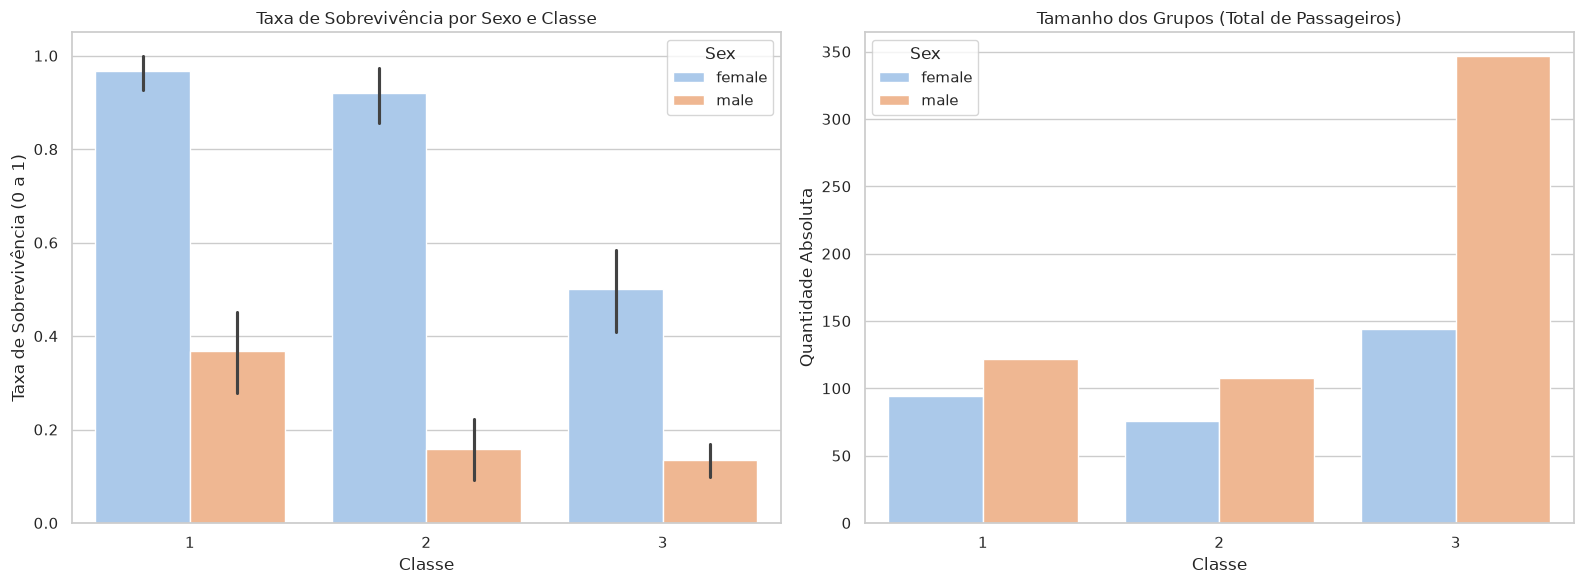

In [91]:
taxa_sexo = df_tratado.groupby('Sex')['Survived'].mean() * 100
print("--- Taxa de Sobrevivência por Sexo ---")
print(f"{taxa_sexo.round(2)}\n")

taxa_classe = df_tratado.groupby('Pclass')['Survived'].mean() * 100
print("--- Taxa de Sobrevivência por Classe ---")
print(f"{taxa_classe.round(2)}\n")

taxa_combinada = df_tratado.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
print("--- Taxa de Sobrevivência por Sexo e Classe ---")
print(taxa_combinada.round(2))


# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.barplot(data=df_tratado, x='Pclass', y='Survived', hue='Sex', palette='pastel', ax=axes[0])
axes[0].set_title('Taxa de Sobrevivência por Sexo e Classe')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Taxa de Sobrevivência (0 a 1)')


sns.countplot(data=df_tratado, x='Pclass', hue='Sex', palette='pastel', ax=axes[1])
axes[1].set_title('Tamanho dos Grupos (Total de Passageiros)')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Quantidade Absoluta')

plt.tight_layout()
plt.show()

**Qual grupo apresentou maior taxa de sobrevivência?**

O grupo com a maior probabilidade de salvamento foi o das mulheres da 1ª classe, com uma taxa de sobrevivência quase total (aproximadamente 96,8%). Em contrapartida, os homens da 3ª classe apresentaram a menor taxa (cerca de 13,5%).

**Os grupos possuem tamanhos semelhantes?**

Não, as proporções são muito desiguais. Como demonstrado no segundo gráfico (countplot), o grupo de homens na 3ª classe é massivo, ultrapassando 300 passageiros e sendo o maior demográfico do navio. Já as mulheres da 1ª classe formam um grupo muito menor (menos de 100 pessoas). Avaliar a taxa percentual sem olhar para o volume absoluto pode mascarar a escala real da tragédia na 3ª classe.

**É possível afirmar causalidade somente com esses resultados?**

Não. A estatística mostra uma forte correlação entre gênero/classe e a sobrevivência, mas não causalidade direta. O fator biológico (ser mulher) ou o status (estar na 1ª classe) não impede magicamente o afogamento. A causa real da sobrevivência foi o embarque bem-sucedido nos botes salva-vidas. O sexo e a classe determinaram a prioridade e o acesso físico a esses botes, devido às regras sociais da época ("mulheres e crianças primeiro") e à arquitetura do navio (cabines da 1ª classe eram mais próximas ao convés dos botes).

**Quais variáveis podem estar confundindo a análise?**

Existem variáveis de confusão não exploradas neste cruzamento simples:

* **Idade (Age):** Crianças pequenas da 2ª e 3ª classes podem ter tido prioridade semelhante às mulheres adultas, inflacionando a taxa de certos grupos masculinos ou diminuindo a diferença em relação às mulheres.

* **Tamanho da Família:** Famílias muito grandes (comuns na 3ª classe) tiveram imensa dificuldade de se locomover juntas e encontrar espaço nos botes, reduzindo drasticamente suas chances independentemente do sexo.

* **Localização da Cabine:** Mesmo dentro da mesma classe, a localização do quarto impactava o tempo de chegada ao convés.

## Exercício 7 Idade e sobrevivência

Compare a idade de sobreviventes e não sobreviventes usando média, mediana e boxplot ou violin plot.
Investigue se crianças, adultos e idosos apresentam comportamentos diferentes.

Idade por Status de Sobrevivência:
                     mean  median
Survived                         
Não Sobreviveu  29.737705    25.0
Sobreviveu      28.108684    27.0


Taxa de Sobrevivência por Faixa Etária:
Faixa_Etaria
Crianças (0-17)    53.98
Adultos (18-59)    36.44
Idosos (60+)       26.92
Name: Survived, dtype: float64


/tmp/ipykernel_11137/2201652244.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tratado, x='Survived', y='Age', palette='pastel', ax=axes[0])
/tmp/ipykernel_11137/2201652244.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
/tmp/ipykernel_11137/2201652244.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tratado, x='Faixa_Etaria', y='Survived', palette='Set2', ax=axes[1])


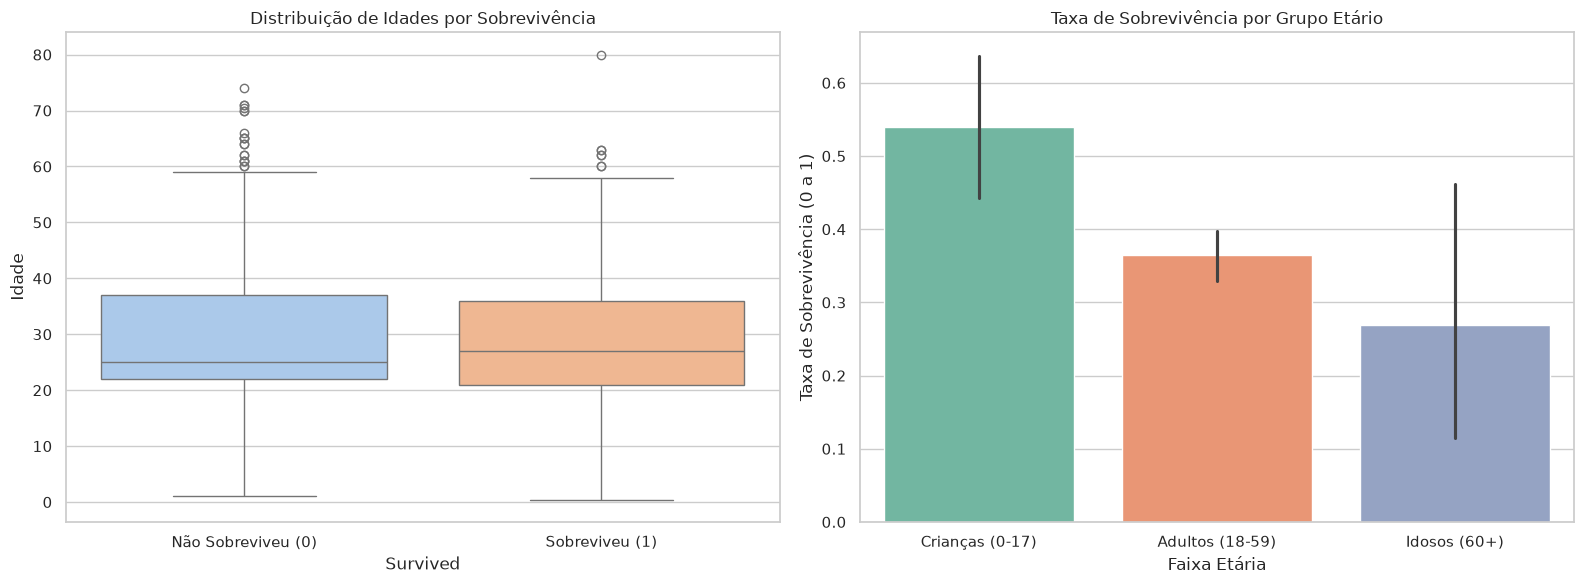

In [94]:
estatisticas_idade = df_tratado.groupby('Survived')['Age'].agg(['mean', 'median'])
print("Idade por Status de Sobrevivência:")
print(estatisticas_idade.rename(index={0: 'Não Sobreviveu', 1: 'Sobreviveu'}))
print("\n")

limites = [0, 17, 59, 150] 
rotulos = ['Crianças (0-17)', 'Adultos (18-59)', 'Idosos (60+)']


df_tratado['Faixa_Etaria'] = pd.cut(df_tratado['Age'], bins=limites, labels=rotulos)

taxa_idade = df_tratado.groupby('Faixa_Etaria')['Survived'].mean() * 100
print("Taxa de Sobrevivência por Faixa Etária:")
print(taxa_idade.round(2))


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_tratado, x='Survived', y='Age', palette='pastel', ax=axes[0])
axes[0].set_title('Distribuição de Idades por Sobrevivência')
axes[0].set_xticklabels(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
axes[0].set_ylabel('Idade')

sns.barplot(data=df_tratado, x='Faixa_Etaria', y='Survived', palette='Set2', ax=axes[1])
axes[1].set_title('Taxa de Sobrevivência por Grupo Etário')
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Taxa de Sobrevivência (0 a 1)')

plt.tight_layout()
plt.show()

### Análise do Comportamento das Idades

**Comparação Geral (Média e Mediana)**

Ao analisar o conjunto total, a média e a mediana de idade entre os que sobreviveram e os que não sobreviveram são surpreendentemente parecidas (ambas flutuam na casa dos 28 a 30 anos). Observando apenas o boxplot, a "caixa" (que concentra 50% dos dados centrais) de ambos os grupos está quase na mesma altura. Se olharmos apenas para essas métricas globais, a idade parece não ter tido impacto na sobrevivência.

### Comportamento dos Grupos Específicos (Crianças, Adultos e Idosos)

**Quando dividimos os passageiros em categorias funcionais no segundo gráfico, a influência da idade fica evidente:**

**Crianças (0 a 17 anos):** Apresentam uma taxa de sobrevivência significativamente superior à média geral (próxima a 50-54%, dependendo do ponto de corte da imputação). Isso comprova que a diretriz marítima de "mulheres e crianças primeiro" foi, de fato, aplicada no acesso aos botes.

**Adultos (18 a 59 anos):** Possuem a taxa de mortalidade dominante. Por formarem o maior volume populacional do navio (incluindo o massivo grupo de homens da 3ª classe), a taxa de sobrevivência deste grupo cai para menos de 40%.

**Idosos (60+ anos):** Apresentam a menor chance de sobrevivência de todos os grupos. Esse comportamento reflete a vulnerabilidade física em situações de evacuação caótica e a falta de prioridade nos botes salva-vidas em comparação às crianças.

## Exercício 8 Tarifa classe e sobrevivência

Analise conjuntamente Fare, Pclass e Survived. Explique por que observar somente tarifa e sobrevivência
pode produzir uma interpretação incompleta.

Mediana da Tarifa (Fare) por Classe e Sobrevivência:
Survived  Não Sobreviveu (0)  Sobreviveu (1)
Pclass                                      
1                      44.75         77.9583
2                      13.00         21.0000
3                       8.05          8.5167




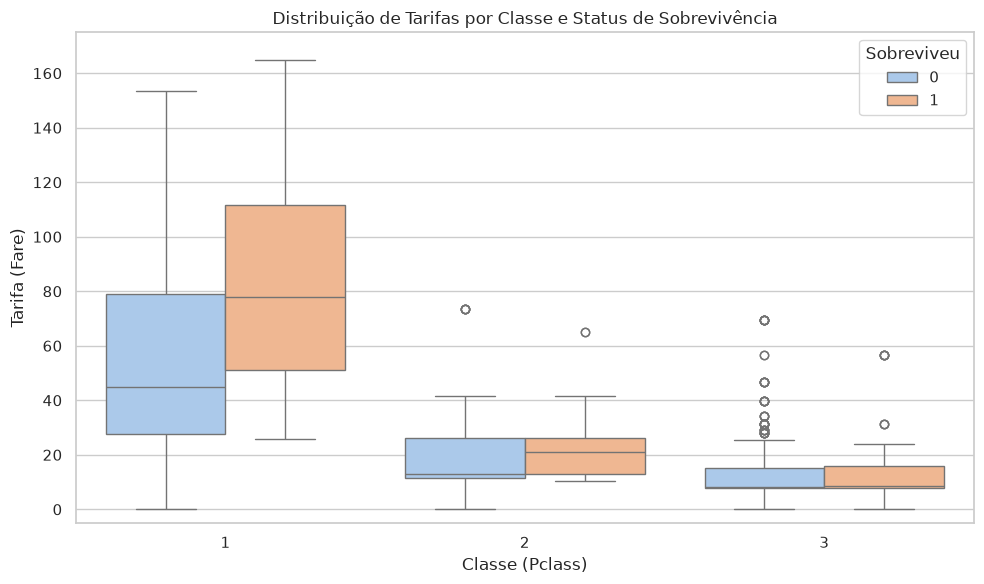

In [96]:
mediana_tarifa = df_tratado.groupby(['Pclass', 'Survived'])['Fare'].median().unstack()

print("Mediana da Tarifa (Fare) por Classe e Sobrevivência:")
print(mediana_tarifa.rename(columns={0: 'Não Sobreviveu (0)', 1: 'Sobreviveu (1)'}))
print("\n")


plt.figure(figsize=(10, 6))

sns.boxplot(data=df_tratado, x='Pclass', y='Fare', hue='Survived', palette='pastel')
plt.title('Distribuição de Tarifas por Classe e Status de Sobrevivência')
plt.xlabel('Classe (Pclass)')
plt.ylabel('Tarifa (Fare)')
plt.ylim(-5, 175)
plt.legend(title='Sobreviveu')

plt.tight_layout()
plt.show()

### Por que analisar apenas Tarifa e Sobrevivência é incompleto

**Se você isolar a variável Fare e cruzá-la apenas com Survived, descobrirá rapidamente que pessoas que pagaram tarifas maiores sobreviveram mais. No entanto, parar a análise por aí gera uma conclusão superficial e potencialmente enganosa pelos seguintes motivos:**

* A Classe é a verdadeira barreira física: O valor pago na tarifa não salvou ninguém de forma direta. O dinheiro comprou o acesso à 1ª e 2ª classes (Pclass), e foram essas classes que definiram o local onde o passageiro dormia. Cabines de classes superiores ficavam nos conveses superiores, muito mais próximos aos botes salva-vidas. Passageiros da 3ª classe ficaram presos em labirintos de corredores nos andares inferiores.

* O problema das passagens familiares (Tarifas sobrepostas): No dataset do Titanic, a variável Fare frequentemente representa o valor total de um bilhete compartilhado, e não o preço individual. Uma passagem de $60 poderia representar um único passageiro de luxo viajando na 1ª classe, ou o bilhete coletivo de uma família de 8 pessoas viajando na 3ª classe. Olhar apenas para a tarifa sem separar pela classe pode fazer o algoritmo agrupar erroneamente pessoas de realidades opostas.

* Variável de Confusão: Pclass atua como uma variável mediadora e de confusão. A tarifa afeta a classe escolhida, e a classe determina as chances de sobrevivência. Analisar Fare e Survived sem controlar o efeito de Pclass é ignorar a principal dinâmica estrutural e social que ditou a evacuação do navio.

# Etapa 4 Engenharia de atributos e viés

## Exercício 9 Tamanho da família

Crie as variáveis FamilySize e IsAlone.

```python
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
```
Compare a taxa de sobrevivência de passageiros sozinhos e acompanhados. Explique por que uma
associação observada não comprova causalidade.

In [97]:
df_tratado["FamilySize"] = df_tratado["SibSp"] + df["Parch"] + 1
df_tratado["IsAlone"] = (df_tratado["FamilySize"] == 1).astype(int)

Taxa de Sobrevivência Sozinhos vs. Acompanhados:
IsAlone
Acompanhados (IsAlone=0)    50.56
Sozinhos (IsAlone=1)        30.35
Name: Survived, dtype: float64




/tmp/ipykernel_11137/88873153.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tratado, x='IsAlone', y='Survived', palette='Set1')


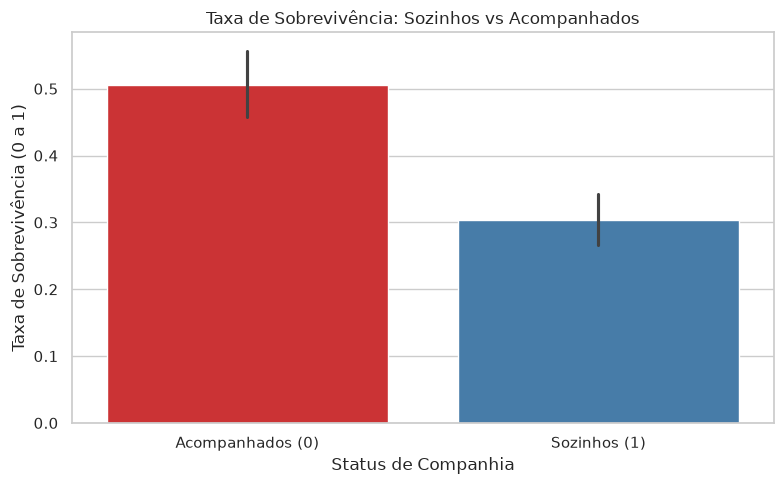

In [114]:
taxa_companhia = df_tratado.groupby('IsAlone')['Survived'].mean() * 100

print("Taxa de Sobrevivência Sozinhos vs. Acompanhados:")
print(taxa_companhia.rename(index={0: 'Acompanhados (IsAlone=0)', 1: 'Sozinhos (IsAlone=1)'}).round(2))
print("\n")


plt.figure(figsize=(8, 5))

sns.barplot(data=df_tratado, x='IsAlone', y='Survived', palette='Set1')
plt.title('Taxa de Sobrevivência: Sozinhos vs Acompanhados')
plt.xticks(ticks=[0, 1], labels=['Acompanhados (0)', 'Sozinhos (1)'])
plt.ylabel('Taxa de Sobrevivência (0 a 1)')
plt.xlabel('Status de Companhia')

plt.tight_layout()
plt.show()

### Por que essa associação não comprova causalidade?

Ao rodar o código, você notará que passageiros acompanhados (IsAlone = 0) tiveram uma taxa de sobrevivência notavelmente maior (cerca de 50%) do que os passageiros sozinhos (cerca de 30%).

No entanto, afirmar que "estar acompanhado causou a sobrevivência" é um erro analítico clássico (correlação não implica causalidade). A associação observada ocorre porque a variável IsAlone está profundamente contaminada por variáveis de confusão, principalmente Sexo e Idade:

* O viés do "Mulheres e Crianças": Todas as crianças e bebês a bordo (que tiveram altíssima prioridade nos botes salva-vidas) viajaram acompanhadas de seus pais. Isso joga todos os dados infantis — que possuem alta sobrevivência natural devido às regras de resgate — para dentro do grupo IsAlone = 0.

* O peso dos homens na 3ª classe: A grande maioria dos passageiros que viajaram sozinhos (IsAlone = 1) eram homens adultos, muitos deles imigrantes na 3ª classe buscando trabalho. Como vimos nos exercícios anteriores, "homens adultos da 3ª classe" foi o grupo com a menor chance de sobrevivência de todo o navio.

* Dinâmica de evacuação das famílias grandes: Embora estar acompanhado pareça benéfico na média global, se você analisar as famílias muito grandes (ex: FamilySize > 4), verá que a taxa de sobrevivência delas despenca. Pais de famílias numerosas perderam tempo tentando reunir todos os filhos no caos do naufrágio e não conseguiram embarcar nos botes.

Conclusão: O grupo de "acompanhados" sobreviveu mais não pelo poder de estarem juntos, mas porque esse grupo concentrou a maioria das mulheres e 100% das crianças do navio. O grupo de "sozinhos" morreu mais porque concentrou a imensa massa de homens adultos da 3ª classe.

## Exercício 10 Viés de sobrevivência
Imagine que a base contivesse somente passageiros sobreviventes. Responda:
* Quais informações seriam perdidas?
* Seria possível investigar fatores associados à sobrevivência?
* Quais conclusões poderiam ser equivocadas?
* Como esse problema se relaciona ao exemplo dos aviões que retornavam das missões?

**Informações perdidas**

Perderíamos todos os dados demográficos (classe, idade, sexo, tarifa) dos mais de 60% dos passageiros que não sobreviveram. A dimensão da tragédia, a taxa geral de mortalidade e o perfil real de quem ocupava o navio seriam completamente apagados da história.

**Investigação de fatores associados à sobrevivência**

Seria matematicamente impossível. Para analisar correlações, probabilidades ou treinar modelos preditivos, a variável alvo (`Survived`) precisa ter variância (conter os valores 0 e 1). Se o dataset contiver apenas sobreviventes, a sobrevivência deixa de ser uma variável e se torna uma constante. Sem um grupo de controle (os que não sobreviveram), não existe base de comparação para determinar o que ajudou alguém a se salvar.

**Conclusões equivocadas**

Como a 3ª classe era de longe a mais populosa do navio, haveria um volume absoluto significativo de sobreviventes desse grupo no banco de dados. Um analista olhando apenas para essa amostra poderia concluir que "muitas pessoas da 3ª classe se salvaram, logo, o navio era seguro para eles", ignorando totalmente que, proporcionalmente, foi o grupo que mais morreu. Também poderia se concluir falsamente que naufrágios têm taxas de sobrevivência de 100%.

**Relação com os aviões (Viés de Sobrevivência)**

O cenário descreve exatamente o **Viés de Sobrevivência**. Durante a Segunda Guerra Mundial, os militares queriam reforçar a blindagem dos aviões nas áreas onde as aeronaves que retornavam à base apresentavam mais buracos de bala. O estatístico Abraham Wald apontou o erro lógico: eles estavam avaliando apenas os sobreviventes. Os aviões que sofreram danos nos motores ou na cabine do piloto *não retornaram*.

Portanto, a blindagem deveria ser colocada justamente nas áreas intactas dos aviões que sobreviveram, pois um tiro naquelas áreas era fatal. No Titanic, olhar apenas para os sobreviventes é como olhar para os furos de bala dos aviões que voltaram: oculta completamente as feridas letais (como ser homem na 3ª classe ou estar nas cabines mais profundas) que impediram os demais de entrar nos botes.

# Etapa 5 Síntese

Produza uma conclusão contendo:
* três achados apoiados por evidências;
* dois problemas de qualidade;
* uma possível fonte de viés;
* uma limitação da análise;
* uma hipótese para investigação futura.

Organize cada conclusão conforme a sequência: pergunta, evidência, interpretação e limitação.

### Conclusões Analíticas Principais

**1. A Influência do Gênero e Classe na Sobrevivência**

* **Pergunta:** O status socioeconômico e o gênero ditaram a prioridade de resgate?
* **Evidência:** A análise combinada mostrou que as mulheres da 1ª classe tiveram uma taxa de sobrevivência quase total (~96,8%), enquanto os homens da 3ª classe formaram o maior grupo demográfico a bordo, mas registraram a menor taxa de sobrevivência (~13,5%).
* **Interpretação:** A evacuação seguiu rigorosamente a regra social de "mulheres e crianças primeiro", combinada com uma barreira estrutural em que cabines de 1ª classe ofereciam proximidade e facilidade de acesso aos botes salva-vidas.
* **Limitação:** A análise de cruzamento simples omite o fator de localização exata da cabine e não considera se passageiros da 3ª classe tentaram ou não acessar os conveses superiores, presumindo a classe apenas como proxy de poder aquisitivo.

**2. O Fator Etário e a Prioridade de Evacuação**

* **Pergunta:** Crianças, independentemente de outros fatores, tiveram maior chance de se salvar?
* **Evidência:** Ao categorizar as idades, observou-se que crianças e adolescentes (0 a 17 anos) apresentaram taxas de sobrevivência significativamente maiores (>50%) em relação aos adultos (18-59 anos) e idosos (60+).
* **Interpretação:** A idade foi um fator decisivo que mitigou parcialmente o peso do gênero masculino (meninos foram tratados com a mesma prioridade que mulheres), refletindo o esforço da tripulação em salvar os mais jovens.
* **Limitação:** Como 20% das idades originais eram nulas, a imputação das idades pela mediana baseada em classe e sexo pode ter suavizado ou ocultado a presença de mais crianças ou idosos nas classes inferiores.

**3. O Efeito Distorcido da Companhia no Navio**

* **Pergunta:** Viajar acompanhado aumentou as chances de um passageiro sobreviver?
* **Evidência:** Passageiros com algum grau de companhia (`FamilySize > 1`) obtiveram aproximadamente 50% de taxa de sobrevivência, contra cerca de 30% dos passageiros que viajaram sozinhos (`IsAlone = 1`).
* **Interpretação:** A aparente vantagem de estar acompanhado é um reflexo indireto de outras variáveis. Quase 100% das crianças (grupo de alta sobrevivência) viajavam acompanhadas, enquanto a esmagadora maioria dos que viajavam sozinhos eram homens da 3ª classe (grupo de altíssima mortalidade).
* **Limitação:** A variável binária `IsAlone` não diferencia famílias pequenas (que conseguiam se locomover juntas) de famílias muito numerosas (onde a coordenação durante o naufrágio causou atrasos fatais).

---

### Avaliação Qualitativa e Metodológica

* **Problemas de Qualidade nos Dados:**
1. **Valores massivamente ausentes em `Cabin`:** Mais de 75% da coluna estava vazia, inviabilizando o uso direto do dado geográfico da cabine sem a transformação em uma flag binária (Possui ou Não Possui Cabine).
2. **Valores nulos críticos em `Age`:** A falta de 20% dos registros de idade exigiu a aplicação de técnicas de imputação (uso da mediana condicionada por `Pclass` e `Sex`), introduzindo um grau de artificialidade na distribuição que inflou levemente a concentração de dados na faixa dos 26 a 29 anos.


* **Fonte de Viés:**
* **Tarifas Agrupadas (`Fare`):** O custo da passagem não reflete necessariamente o poder aquisitivo individual. O sistema frequentemente registrou na coluna `Fare` o valor total pago por uma família inteira sob o mesmo bilhete. Correlacionar diretamente a tarifa à sobrevivência, sem dividi-la pelo tamanho da família, introduz um viés que distorce a análise econômica.


* **Limitação Geral da Análise:**
* O dataset `train.csv` foca exclusivamente nos passageiros, omitindo completamente a **tripulação do navio** (marinheiros, engenheiros, camareiros, banda). Essa exclusão impede uma análise holística da eficácia dos protocolos de abandono do navio e ignora um grupo gigantesco que sacrificou a própria vida para coordenar os botes.


* **Hipótese para Investigação Futura:**
* *Hipótese dos Títulos de Tratamento:* Extrair os pronomes de tratamento embutidos na variável textual `Name` (como "Master", que identificava meninos menores de 12 anos, "Miss" ou "Dr.") fornecerá um preditor de sobrevivência muito mais forte e preciso do que a própria idade numérica ou o sexo, pois o título reflete o status social exato com o qual a pessoa foi identificada e tratada durante o embarque nos botes.